<a href="https://colab.research.google.com/github/Methura/Methura-PM/blob/main/objectmeasurement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cpu

0: 640x480 4 persons, 1 bus, 1 stop sign, 418.2ms
Speed: 14.5ms preprocess, 418.2ms inference, 44.2ms postprocess per image at shape (1, 3, 640, 480)
bus: Width=783, Height=525, Area=411075
person: Width=197, Height=504, Area=99288
person: Width=140, Height=485, Area=67900
person: Width=123, Height=452, Area=55596
person: Width=63, Height=323, Area=20349
stop sign: Width=32, Height=70, Area=2240

Total Objects Detected: 6
Inference Time: 0.71494460105896 seconds

0: 640x480 4 persons, 1 bus, 1 stop sign, 185.7ms
Speed: 4.7ms preprocess, 185.7ms inference, 1.7ms postprocess per image at 

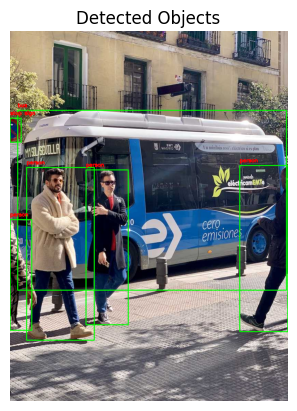

In [ ]:
!pip install ultralytics opencv-python matplotlib
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)
model = YOLO("yolov8n.pt")
model.to(device)
import urllib.request
url = "https://ultralytics.com/images/bus.jpg"
urllib.request.urlretrieve(url, "sample.jpg")
image = cv2.imread("sample.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Input Image")
plt.axis("off")
start_time = time.time()
results = model(image)
end_time = time.time()
inference_time = end_time - start_time
detections = results[0]
object_count = 0
for box in detections.boxes:
    object_count += 1
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls = int(box.cls[0])
    label = model.names[cls]
    width = x2 - x1
    height = y2 - y1
    area = width * height
    print(f"{label}: Width={width}, Height={height}, Area={area}")
    cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(image_rgb, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
print("\nTotal Objects Detected:", object_count)
print("Inference Time:", inference_time, "seconds")
plt.imshow(image_rgb)
plt.title("Detected Objects")
plt.axis("off")
runs = 10
times = []
for i in range(runs):
    start = time.time()
    _ = model(image)
    end = time.time()
    times.append(end - start)
avg_latency = sum(times) / len(times)
print("Average Latency:", avg_latency, "seconds")
print("Min Latency:", min(times))
print("Max Latency:", max(times))
model_cpu = YOLO("yolov8n.pt")
model_cpu.to('cpu')
model_gpu = YOLO("yolov8n.pt")
model_gpu.to(device)
def measure_latency(model, device):
    times = []
    for _ in range(5):
        start = time.time()
        _ = model(image)
        end = time.time()
        times.append(end - start)
    return sum(times)/len(times)

cpu_latency = measure_latency(model_cpu, 'cpu')
gpu_latency = measure_latency(model_gpu, device)
print("\n--- Latency Comparison ---")
print("CPU Latency:", cpu_latency)
print("GPU Latency:", gpu_latency)